<a href="https://colab.research.google.com/github/dominicwooldridge/GSB-S544/blob/Practice-Activities/Copy_of_Practice_Activity_9_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Our dataset consists of clinical data from patients who entered the hospital complaining of chest pain ("angina") during exercise.  The information collected includes:

* `age` : Age of the patient

* `sex` : Sex of the patient

* `cp` : Chest Pain type

    + Value 0: asymptomatic
    + Value 1: typical angina
    + Value 2: atypical angina
    + Value 3: non-anginal pain
   
    
* `trtbps` : resting blood pressure (in mm Hg)

* `chol` : cholesterol in mg/dl fetched via BMI sensor

* `restecg` : resting electrocardiographic results

    + Value 0: normal
    + Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
    + Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria

* `thalach` : maximum heart rate achieved during exercise

* `output` : the doctor's diagnosis of whether the patient is at risk for a heart attack
    + 0 = not at risk of heart attack
    + 1 = at risk of heart attack

In [1]:
## library imports here
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [2]:
ha = pd.read_csv("https://www.dropbox.com/s/aohbr6yb9ifmc8w/heart_attack.csv?dl=1")

## Q1: Natural Multiclass Models

Fit a multiclass KNN, Decision Tree, and LDA for the heart disease data; this time predicting the type of chest pain (categories 0 - 3) that a patient experiences.  For the decision tree, plot the fitted tree, and interpret the first couple splits.


In [3]:
from sklearn.model_selection import train_test_split

X = ha.drop(columns=["cp"])
y = ha["cp"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

knn_preds = knn.predict(X_test)
print("KNN accuracy:", accuracy_score(y_test, knn_preds))


KNN accuracy: 0.4727272727272727


In [5]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

lda_preds = lda.predict(X_test)
print("LDA accuracy:", accuracy_score(y_test, lda_preds))


LDA accuracy: 0.4727272727272727


Decision Tree accuracy: 0.5272727272727272


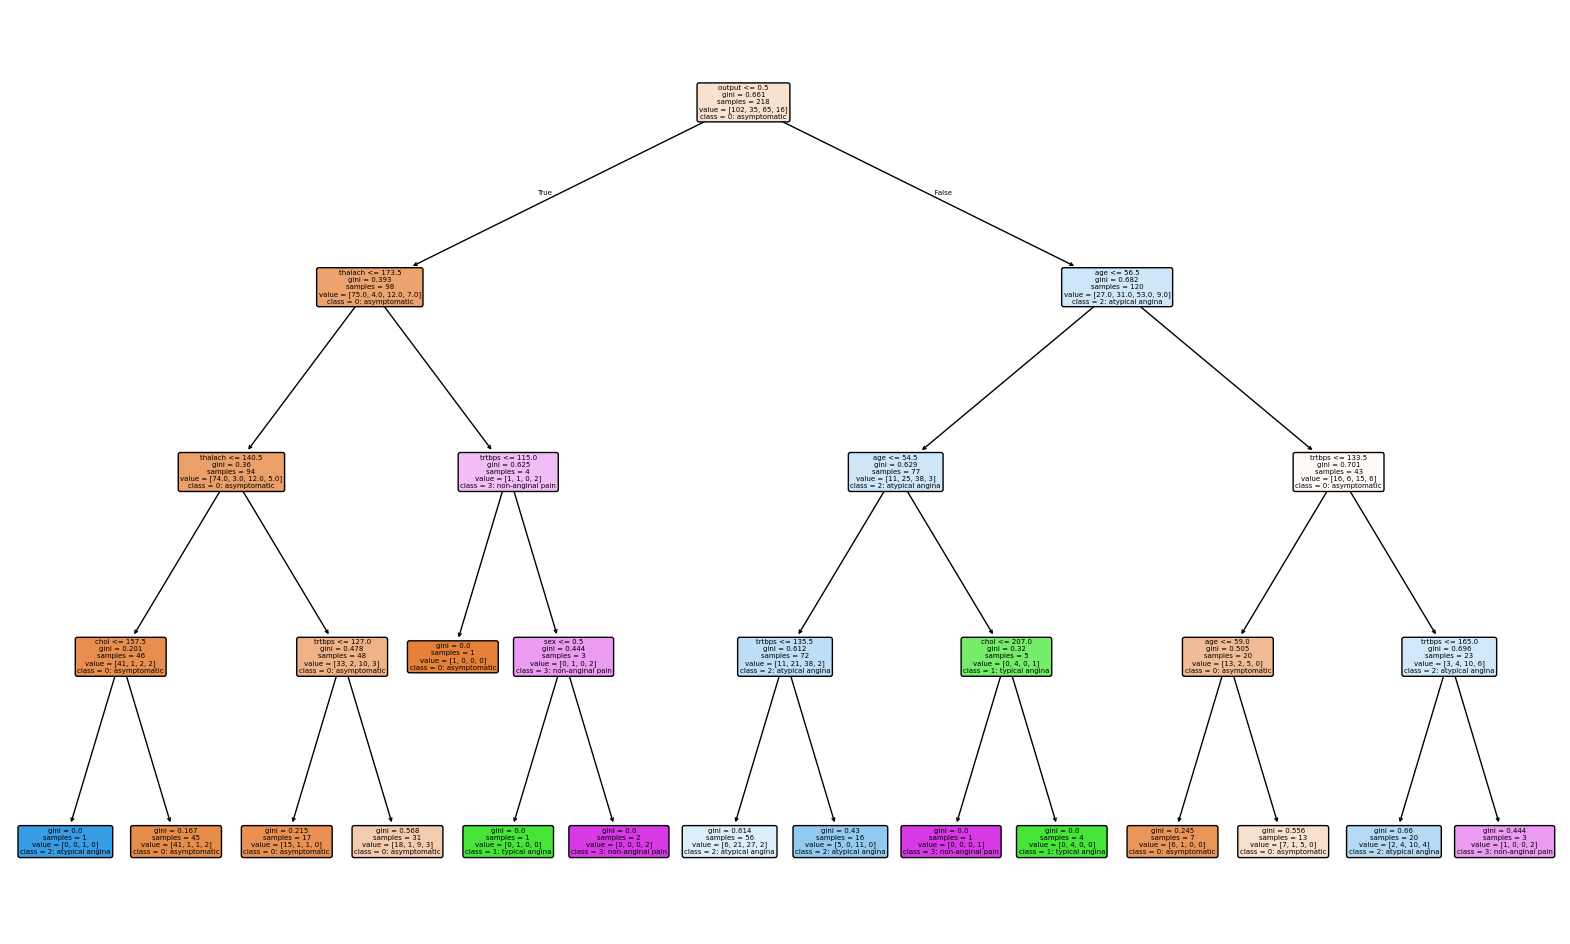

In [6]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

dt = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

dt.fit(X_train, y_train)

dt_preds = dt.predict(X_test)
print("Decision Tree accuracy:", accuracy_score(y_test, dt_preds))

plt.figure(figsize=(20, 12))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=[
        "0: asymptomatic",
        "1: typical angina",
        "2: atypical angina",
        "3: non-anginal pain"
    ],
    filled=True,
    rounded=True
)
plt.show()


## Q2:  OvR

Create a new column in the `ha` dataset called `cp_is_3`, which is equal to `1` if the `cp` variable is equal to `3` and `0` otherwise.

Then, fit a Logistic Regression to predict this new target, and report the **F1 Score**.

Repeat for the other three `cp` categories.  Which category was the OvR approach best at distinguishing?

In [7]:
import pandas as pd

ha["cp_is_0"] = (ha["cp"] == 0).astype(int)
ha["cp_is_1"] = (ha["cp"] == 1).astype(int)
ha["cp_is_2"] = (ha["cp"] == 2).astype(int)
ha["cp_is_3"] = (ha["cp"] == 3).astype(int)


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

def ovr_logistic_f1(target_col):
    X = ha.drop(columns=["cp", "cp_is_0", "cp_is_1", "cp_is_2", "cp_is_3"])
    y = ha[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    logreg = LogisticRegression(max_iter=500)
    logreg.fit(X_train, y_train)

    preds = logreg.predict(X_test)
    f1 = f1_score(y_test, preds)

    return f1


In [9]:
f1_0 = ovr_logistic_f1("cp_is_0")
f1_1 = ovr_logistic_f1("cp_is_1")
f1_2 = ovr_logistic_f1("cp_is_2")
f1_3 = ovr_logistic_f1("cp_is_3")

print("F1 cp=0:", f1_0)
print("F1 cp=1:", f1_1)
print("F1 cp=2:", f1_2)
print("F1 cp=3:", f1_3)


F1 cp=0: 0.75
F1 cp=1: 0.0
F1 cp=2: 0.1
F1 cp=3: 0.0


## Q3: OvO

Reduce your dataset to only the `0` and `1` types of chest pain.

Then, fit a Logistic Regression to predict between the two groups, and report the **ROC-AUC**.  

Repeat comparing category `0` to `2` and `3`.  Which pair was the OvO approach best at distinguishing?

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

def ovo_auc(cp_a, cp_b):

    df = ha[ha["cp"].isin([cp_a, cp_b])].copy()

    df["target"] = (df["cp"] == cp_b).astype(int)

    X = df.drop(columns=["cp", "target"])
    y = df["target"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    logreg = LogisticRegression(max_iter=1000)
    logreg.fit(X_train, y_train)

    y_proba = logreg.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_proba)
    return auc


In [11]:
auc_01 = ovo_auc(0, 1)
print("AUC (0 vs 1):", auc_01)


AUC (0 vs 1): 1.0


In [12]:
auc_02 = ovo_auc(0, 2)
print("AUC (0 vs 2):", auc_02)


AUC (0 vs 2): 1.0


In [13]:
auc_03 = ovo_auc(0, 3)
print("AUC (0 vs 3):", auc_03)


AUC (0 vs 3): 1.0
